# 12 — `pac`: full phase-amplitude coupling map

`pac, pha_bands, amp_bands = dsp.pac(x, fs, ...)` sweeps a grid of
phase- and amplitude-frequency bands and returns one MI per pair —
ready to plot as a heatmap.

`scitex_dsp.utils.pac.calc_pac_with_tensorpac` runs `tensorpac.Pac`
over the same input under matched conditions so the two MI maps are
directly comparable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scitex_dsp as dsp
from scitex_dsp.utils.pac import calc_pac_with_tensorpac
%matplotlib inline

xx, tt, fs = dsp.demo_sig(sig_type="tensorpac", batch_size=2, n_chs=2,
                          n_segments=2, t_sec=4, fs=512)
print("input:", xx.shape)

input: (2, 2, 2, 2048)


## scitex-dsp

In [2]:
pac_scitex, freqs_pha, freqs_amp = dsp.pac(
    xx, fs=fs, batch_size=2,
    pha_n_bands=50, amp_n_bands=30,
    device="cpu",
)
i_batch, i_ch = 0, 0
pac_scitex = np.asarray(pac_scitex)[i_batch, i_ch]
print("scitex MI:", pac_scitex.shape)

scitex MI: (50, 30)


## tensorpac (matched conditions)

In [3]:
phases, amplitudes, freqs_pha, freqs_amp, pac_tp = calc_pac_with_tensorpac(
    xx, fs, t_sec=4, i_batch=i_batch, i_ch=i_ch,
)
print("tensorpac MI:", pac_tp.shape)

Phase Amplitude Coupling object defined


INFO: Phase Amplitude Coupling object defined


    true PAC estimation using Modulation Index (MI, Tort et al. 2010)


INFO:     true PAC estimation using Modulation Index (MI, Tort et al. 2010)


tensorpac MI: (50, 30)


## Aligned side-by-side + difference

All three panels share the same `x`/`y` extents (phase × amp
frequencies) and the same color scale (`vmin/vmax`) so the visual
comparison is fair.

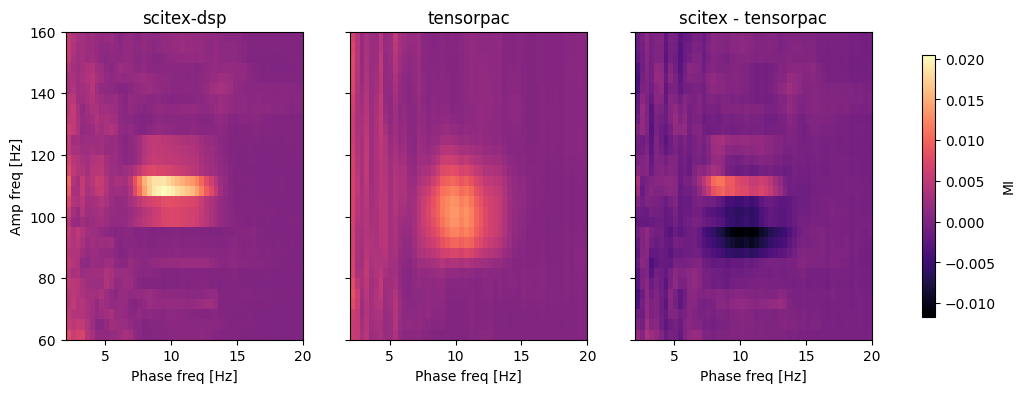

In [4]:
diff = pac_scitex - pac_tp

vmin = float(min(pac_scitex.min(), pac_tp.min(), diff.min()))
vmax = float(max(pac_scitex.max(), pac_tp.max(), diff.max()))
extent = [freqs_pha.min(), freqs_pha.max(),
          freqs_amp.min(), freqs_amp.max()]

fig, axes = plt.subplots(1, 3, figsize=(13, 4),
                         sharex=True, sharey=True)
imshow_kw = dict(origin="lower", aspect="auto", extent=extent,
                 cmap="magma", vmin=vmin, vmax=vmax)

axes[0].imshow(pac_scitex.T, **imshow_kw); axes[0].set_title("scitex-dsp")
axes[1].imshow(pac_tp.T,     **imshow_kw); axes[1].set_title("tensorpac")
im2 = axes[2].imshow(diff.T, **imshow_kw); axes[2].set_title("scitex - tensorpac")

axes[0].set_ylabel("Amp freq [Hz]")
for ax in axes:
    ax.set_xlabel("Phase freq [Hz]")
fig.colorbar(im2, ax=axes, label="MI", shrink=0.85)
plt.show()

Both heatmaps should peak around the injected coupling
(≈10 Hz phase, ≈100 Hz amplitude). The difference panel highlights
where the two implementations diverge — usually small offsets from
band-width / binning conventions.